<a href="https://colab.research.google.com/github/baanujan-18/PLC---Automation/blob/main/plc-occupancy-controlled-fan-system/colab/occupancy-fan-control-verification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PLC-Based Occupancy-Controlled Fan System

This notebook generates a documentation ladder diagram for an occupancy-controlled three-fan system.

- S1 / I0.0: Entry count
- S2 / I0.1: Exit count
- Q0.0: Fan 1
- Q0.1: Fan 2
- Q0.2: Fan 3

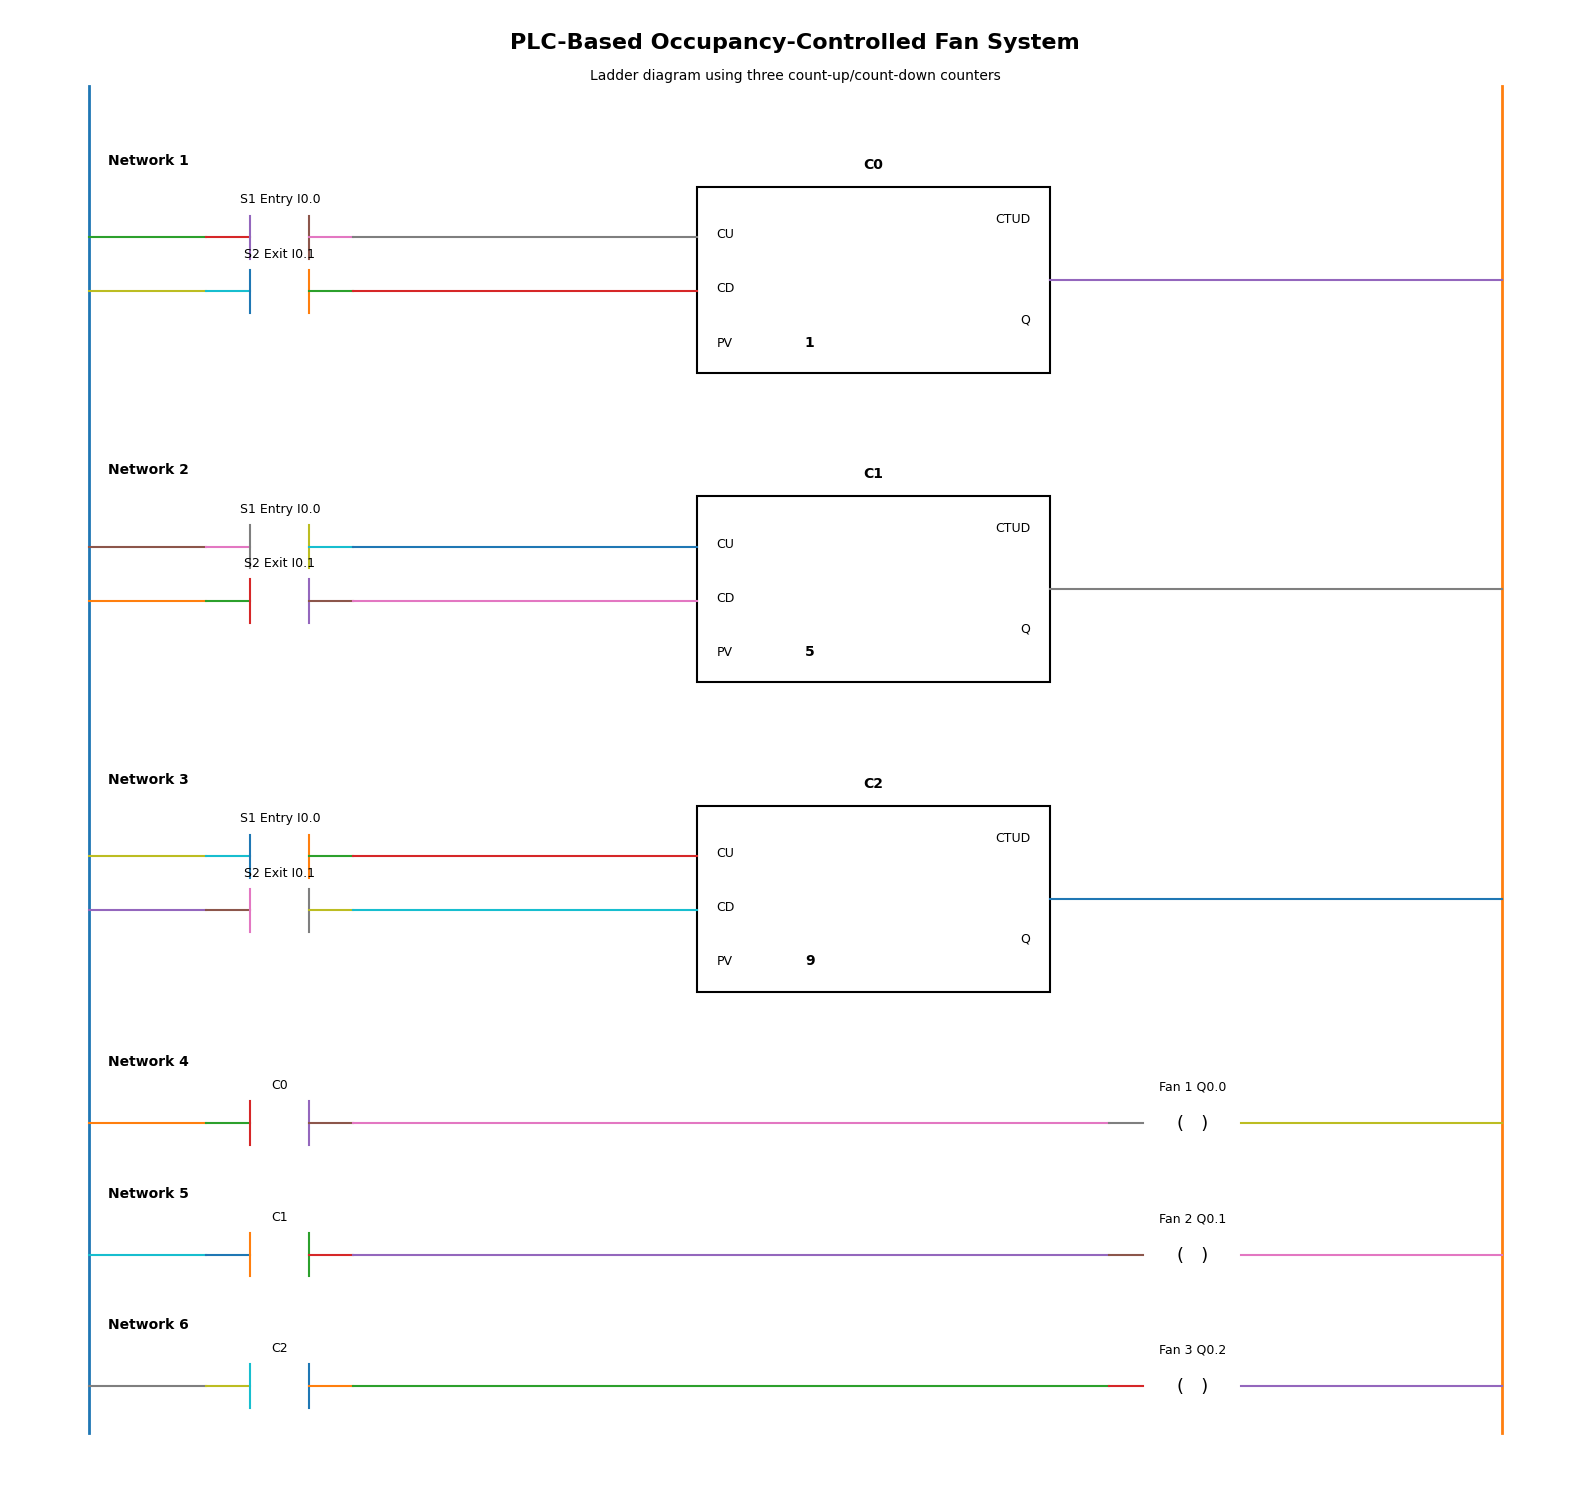

Created:
occupancy_fan_control_ladder.png
occupancy_fan_control_ladder.pdf


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------------------------------------------------------
# Figure setup
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 15))

ax.set_xlim(0, 16)
ax.set_ylim(0, 19)
ax.axis("off")

LEFT_RAIL = 0.8
RIGHT_RAIL = 15.2

# Main ladder rails
ax.plot([LEFT_RAIL, LEFT_RAIL], [0.6, 18], linewidth=2)
ax.plot([RIGHT_RAIL, RIGHT_RAIL], [0.6, 18], linewidth=2)


# ---------------------------------------------------------
# Drawing functions
# ---------------------------------------------------------

def wire(x1, x2, y):
    ax.plot([x1, x2], [y, y], linewidth=1.5)


def contact(x, y, label):
    """Draw a normally open contact."""

    wire(x, x + 0.45, y)

    ax.plot(
        [x + 0.45, x + 0.45],
        [y - 0.28, y + 0.28],
        linewidth=1.5
    )

    ax.plot(
        [x + 1.05, x + 1.05],
        [y - 0.28, y + 0.28],
        linewidth=1.5
    )

    wire(x + 1.05, x + 1.5, y)

    ax.text(
        x + 0.75,
        y + 0.45,
        label,
        ha="center",
        fontsize=9
    )

    return x + 1.5


def coil(x, y, label):
    """Draw a standard output coil."""

    wire(x, x + 0.35, y)

    ax.text(
        x + 0.85,
        y,
        "(   )",
        ha="center",
        va="center",
        fontsize=13
    )

    ax.text(
        x + 0.85,
        y + 0.43,
        label,
        ha="center",
        fontsize=9
    )

    wire(x + 1.35, RIGHT_RAIL, y)


def ctud_block(x, y, counter_name, preset):
    """Draw a count-up/count-down counter block."""

    width = 3.6
    height = 2.4

    block = Rectangle(
        (x, y - height / 2),
        width,
        height,
        fill=False,
        linewidth=1.5
    )

    ax.add_patch(block)

    # Counter name
    ax.text(
        x + width / 2,
        y + 1.45,
        counter_name,
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

    # Function name
    ax.text(
        x + width - 0.2,
        y + 0.75,
        "CTUD",
        ha="right",
        fontsize=9
    )

    # Input labels
    ax.text(x + 0.2, y + 0.55, "CU", fontsize=9)
    ax.text(x + 0.2, y - 0.15, "CD", fontsize=9)
    ax.text(x + 0.2, y - 0.85, "PV", fontsize=9)

    # Preset value
    ax.text(
        x + 1.1,
        y - 0.85,
        str(preset),
        fontsize=10,
        fontweight="bold"
    )

    # Counter output label
    ax.text(
        x + width - 0.2,
        y - 0.55,
        "Q",
        ha="right",
        fontsize=9
    )

    return x + width


def draw_counter_network(network_number, y, counter_name, preset):
    """Draw one CTUD network."""

    ax.text(
        1.0,
        y + 1.5,
        f"Network {network_number}",
        fontsize=10,
        fontweight="bold"
    )

    # Entry input connected to CU
    wire(LEFT_RAIL, 2.0, y + 0.55)

    entry_end = contact(
        2.0,
        y + 0.55,
        "S1 Entry I0.0"
    )

    wire(entry_end, 7.0, y + 0.55)

    # Exit input connected to CD
    wire(LEFT_RAIL, 2.0, y - 0.15)

    exit_end = contact(
        2.0,
        y - 0.15,
        "S2 Exit I0.1"
    )

    wire(exit_end, 7.0, y - 0.15)

    # Counter block
    counter_end = ctud_block(
        7.0,
        y,
        counter_name,
        preset
    )

    wire(counter_end, RIGHT_RAIL, y)


# ---------------------------------------------------------
# Counter networks
# ---------------------------------------------------------

# Fan 1 becomes active from one person
draw_counter_network(
    network_number=1,
    y=15.5,
    counter_name="C0",
    preset=1
)

# Fan 2 becomes active from five people
draw_counter_network(
    network_number=2,
    y=11.5,
    counter_name="C1",
    preset=5
)

# Fan 3 becomes active from nine people
draw_counter_network(
    network_number=3,
    y=7.5,
    counter_name="C2",
    preset=9
)


# ---------------------------------------------------------
# Output networks
# ---------------------------------------------------------

# Network 4: C0 controls Fan 1
y = 4.6

ax.text(
    1.0,
    y + 0.75,
    "Network 4",
    fontsize=10,
    fontweight="bold"
)

wire(LEFT_RAIL, 2.0, y)
end_contact = contact(2.0, y, "C0")
wire(end_contact, 11.2, y)
coil(11.2, y, "Fan 1 Q0.0")


# Network 5: C1 controls Fan 2
y = 2.9

ax.text(
    1.0,
    y + 0.75,
    "Network 5",
    fontsize=10,
    fontweight="bold"
)

wire(LEFT_RAIL, 2.0, y)
end_contact = contact(2.0, y, "C1")
wire(end_contact, 11.2, y)
coil(11.2, y, "Fan 2 Q0.1")


# Network 6: C2 controls Fan 3
y = 1.2

ax.text(
    1.0,
    y + 0.75,
    "Network 6",
    fontsize=10,
    fontweight="bold"
)

wire(LEFT_RAIL, 2.0, y)
end_contact = contact(2.0, y, "C2")
wire(end_contact, 11.2, y)
coil(11.2, y, "Fan 3 Q0.2")


# ---------------------------------------------------------
# Title and export
# ---------------------------------------------------------

ax.text(
    8.0,
    18.5,
    "PLC-Based Occupancy-Controlled Fan System",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    8.0,
    18.1,
    "Ladder diagram using three count-up/count-down counters",
    ha="center",
    fontsize=10
)

plt.tight_layout()

# Save as PNG image
plt.savefig(
    "occupancy_fan_control_ladder.png",
    dpi=300,
    bbox_inches="tight"
)

# Save as PDF
plt.savefig(
    "occupancy_fan_control_ladder.pdf",
    bbox_inches="tight"
)

plt.show()

print("Created:")
print("occupancy_fan_control_ladder.png")
print("occupancy_fan_control_ladder.pdf")

In [2]:
from google.colab import files

files.download("occupancy_fan_control_ladder.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from google.colab import files

files.download("occupancy_fan_control_ladder.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

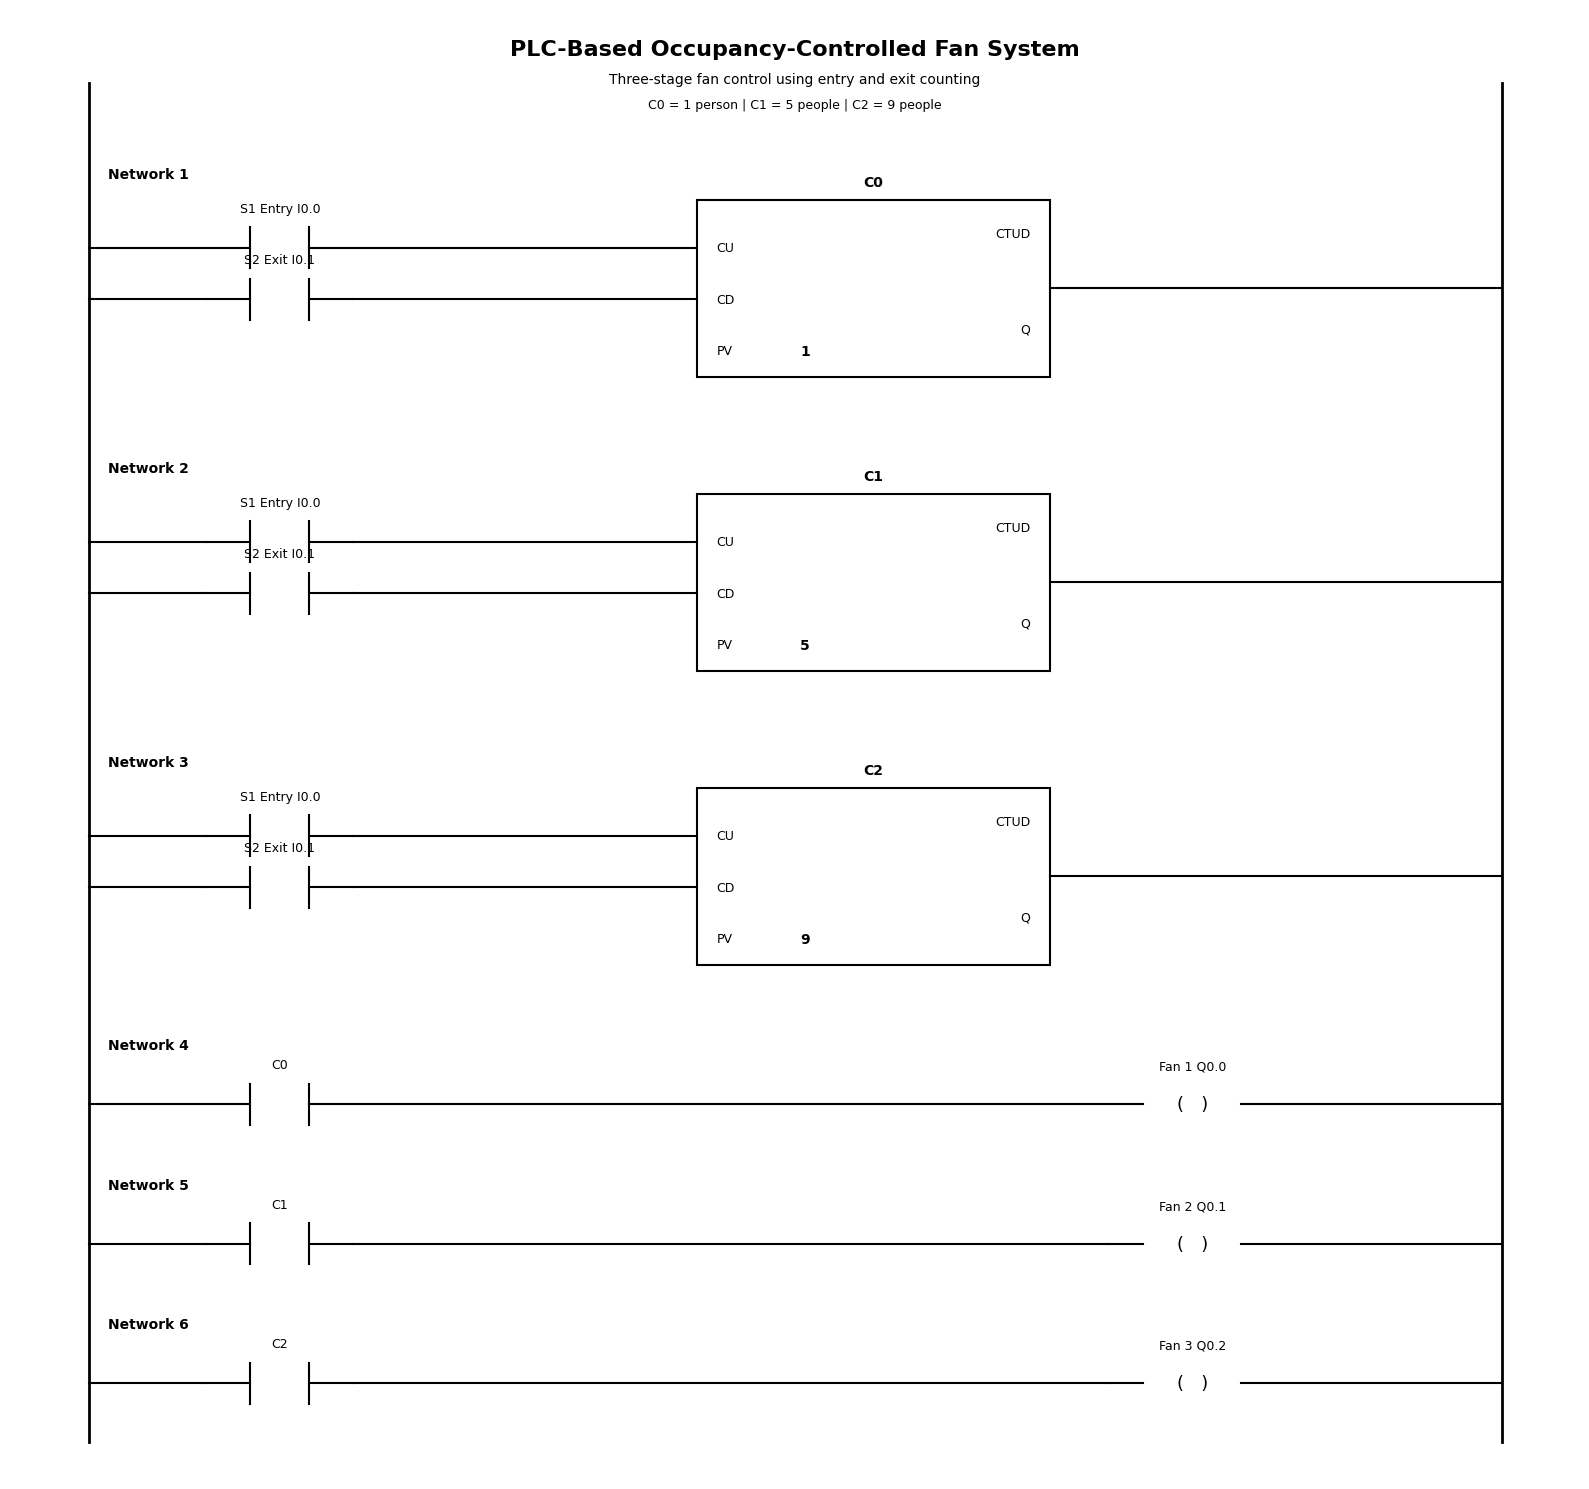

Files created successfully:
occupancy_fan_control_ladder_bw.png
occupancy_fan_control_ladder_bw.pdf


In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =========================================================
# BLACK-AND-WHITE DRAWING SETTINGS
# =========================================================

BLACK = "black"
WHITE = "white"

plt.rcParams["text.color"] = BLACK
plt.rcParams["axes.edgecolor"] = BLACK
plt.rcParams["figure.facecolor"] = WHITE
plt.rcParams["axes.facecolor"] = WHITE
plt.rcParams["savefig.facecolor"] = WHITE


# =========================================================
# FIGURE SETUP
# =========================================================

fig, ax = plt.subplots(
    figsize=(16, 15),
    facecolor=WHITE
)

ax.set_facecolor(WHITE)
ax.set_xlim(0, 16)
ax.set_ylim(0, 20)
ax.axis("off")

LEFT_RAIL = 0.8
RIGHT_RAIL = 15.2

# Main ladder rails
ax.plot(
    [LEFT_RAIL, LEFT_RAIL],
    [0.5, 19],
    linewidth=2,
    color=BLACK
)

ax.plot(
    [RIGHT_RAIL, RIGHT_RAIL],
    [0.5, 19],
    linewidth=2,
    color=BLACK
)


# =========================================================
# DRAWING FUNCTIONS
# =========================================================

def wire(x1, x2, y, linewidth=1.5):
    """Draw a horizontal wire."""
    ax.plot(
        [x1, x2],
        [y, y],
        linewidth=linewidth,
        color=BLACK
    )


def vertical_wire(x, y1, y2, linewidth=1.5):
    """Draw a vertical wire."""
    ax.plot(
        [x, x],
        [y1, y2],
        linewidth=linewidth,
        color=BLACK
    )


def contact(x, y, label, normally_closed=False):
    """
    Draw a normally open or normally closed contact.

    normally_closed=False -> normally open contact
    normally_closed=True  -> normally closed contact
    """

    wire(x, x + 0.45, y)

    ax.plot(
        [x + 0.45, x + 0.45],
        [y - 0.28, y + 0.28],
        linewidth=1.5,
        color=BLACK
    )

    ax.plot(
        [x + 1.05, x + 1.05],
        [y - 0.28, y + 0.28],
        linewidth=1.5,
        color=BLACK
    )

    if normally_closed:
        ax.plot(
            [x + 0.40, x + 1.10],
            [y - 0.34, y + 0.34],
            linewidth=1.5,
            color=BLACK
        )

    wire(x + 1.05, x + 1.5, y)

    ax.text(
        x + 0.75,
        y + 0.45,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        color=BLACK
    )

    return x + 1.5


def coil(x, y, label):
    """Draw a standard output coil."""

    wire(x, x + 0.35, y)

    ax.text(
        x + 0.85,
        y,
        "(   )",
        ha="center",
        va="center",
        fontsize=13,
        color=BLACK
    )

    ax.text(
        x + 0.85,
        y + 0.43,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        color=BLACK
    )

    wire(x + 1.35, RIGHT_RAIL, y)


def ctud_block(x, y, counter_name, preset):
    """
    Draw an up/down counter block.

    CU = Count up
    CD = Count down
    PV = Preset value
    Q  = Counter output
    """

    width = 3.6
    height = 2.4

    block = Rectangle(
        (x, y - height / 2),
        width,
        height,
        fill=False,
        linewidth=1.5,
        edgecolor=BLACK
    )

    ax.add_patch(block)

    # Counter name
    ax.text(
        x + width / 2,
        y + 1.45,
        counter_name,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=BLACK
    )

    # Function name
    ax.text(
        x + width - 0.2,
        y + 0.75,
        "CTUD",
        ha="right",
        va="center",
        fontsize=9,
        color=BLACK
    )

    # Input labels
    ax.text(
        x + 0.2,
        y + 0.55,
        "CU",
        ha="left",
        va="center",
        fontsize=9,
        color=BLACK
    )

    ax.text(
        x + 0.2,
        y - 0.15,
        "CD",
        ha="left",
        va="center",
        fontsize=9,
        color=BLACK
    )

    ax.text(
        x + 0.2,
        y - 0.85,
        "PV",
        ha="left",
        va="center",
        fontsize=9,
        color=BLACK
    )

    # Preset value
    ax.text(
        x + 1.1,
        y - 0.85,
        str(preset),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=BLACK
    )

    # Counter output
    ax.text(
        x + width - 0.2,
        y - 0.55,
        "Q",
        ha="right",
        va="center",
        fontsize=9,
        color=BLACK
    )

    return x + width


def network_label(network_number, y):
    """Draw the network title."""

    ax.text(
        1.0,
        y + 1.5,
        f"Network {network_number}",
        fontsize=10,
        fontweight="bold",
        color=BLACK
    )


def draw_counter_network(
    network_number,
    y,
    counter_name,
    preset
):
    """
    Draw one occupancy counter network.

    S1 I0.0 increments the counter.
    S2 I0.1 decrements the counter.
    """

    network_label(network_number, y)

    # Entry input to count-up input
    wire(LEFT_RAIL, 2.0, y + 0.55)

    entry_end = contact(
        2.0,
        y + 0.55,
        "S1 Entry I0.0"
    )

    wire(entry_end, 7.0, y + 0.55)

    # Exit input to count-down input
    wire(LEFT_RAIL, 2.0, y - 0.15)

    exit_end = contact(
        2.0,
        y - 0.15,
        "S2 Exit I0.1"
    )

    wire(exit_end, 7.0, y - 0.15)

    # Counter block
    counter_end = ctud_block(
        7.0,
        y,
        counter_name,
        preset
    )

    # Connect counter block to right rail
    wire(
        counter_end,
        RIGHT_RAIL,
        y
    )


# =========================================================
# COUNTER NETWORKS
# =========================================================

# Network 1
# Fan 1 becomes active when occupancy reaches 1
draw_counter_network(
    network_number=1,
    y=16.2,
    counter_name="C0",
    preset=1
)

# Network 2
# Fan 2 becomes active when occupancy reaches 5
draw_counter_network(
    network_number=2,
    y=12.2,
    counter_name="C1",
    preset=5
)

# Network 3
# Fan 3 becomes active when occupancy reaches 9
draw_counter_network(
    network_number=3,
    y=8.2,
    counter_name="C2",
    preset=9
)


# =========================================================
# FAN OUTPUT NETWORKS
# =========================================================

# Network 4: C0 controls Fan 1
y = 5.1

ax.text(
    1.0,
    y + 0.75,
    "Network 4",
    fontsize=10,
    fontweight="bold",
    color=BLACK
)

wire(LEFT_RAIL, 2.0, y)

end_contact = contact(
    2.0,
    y,
    "C0"
)

wire(
    end_contact,
    11.2,
    y
)

coil(
    11.2,
    y,
    "Fan 1 Q0.0"
)


# Network 5: C1 controls Fan 2
y = 3.2

ax.text(
    1.0,
    y + 0.75,
    "Network 5",
    fontsize=10,
    fontweight="bold",
    color=BLACK
)

wire(LEFT_RAIL, 2.0, y)

end_contact = contact(
    2.0,
    y,
    "C1"
)

wire(
    end_contact,
    11.2,
    y
)

coil(
    11.2,
    y,
    "Fan 2 Q0.1"
)


# Network 6: C2 controls Fan 3
y = 1.3

ax.text(
    1.0,
    y + 0.75,
    "Network 6",
    fontsize=10,
    fontweight="bold",
    color=BLACK
)

wire(LEFT_RAIL, 2.0, y)

end_contact = contact(
    2.0,
    y,
    "C2"
)

wire(
    end_contact,
    11.2,
    y
)

coil(
    11.2,
    y,
    "Fan 3 Q0.2"
)


# =========================================================
# TITLE AND PROJECT INFORMATION
# =========================================================

ax.text(
    8.0,
    19.45,
    "PLC-Based Occupancy-Controlled Fan System",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color=BLACK
)

ax.text(
    8.0,
    19.05,
    "Three-stage fan control using entry and exit counting",
    ha="center",
    va="center",
    fontsize=10,
    color=BLACK
)

ax.text(
    8.0,
    18.7,
    "C0 = 1 person | C1 = 5 people | C2 = 9 people",
    ha="center",
    va="center",
    fontsize=9,
    color=BLACK
)


# =========================================================
# SAVE AND DISPLAY
# =========================================================

plt.tight_layout()

# Save high-resolution PNG for LinkedIn and GitHub
plt.savefig(
    "occupancy_fan_control_ladder_bw.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=WHITE
)

# Save PDF for GitHub documentation
plt.savefig(
    "occupancy_fan_control_ladder_bw.pdf",
    bbox_inches="tight",
    facecolor=WHITE
)

plt.show()

print("Files created successfully:")
print("occupancy_fan_control_ladder_bw.png")
print("occupancy_fan_control_ladder_bw.pdf")

In [5]:
from google.colab import files

files.download("occupancy_fan_control_ladder_bw.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>